# Quantitative Analysis Using PyNance and TA-Lib
# Task 2

Yordanos Birhanu
 Date 5/12/2026

Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
# import pynance as pn
import yfinance as yf

plt.style.use('ggplot')

Load the 5 Datasets

In [5]:
df1 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\AAPL.csv")
df2 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\AMZN.csv")
df3 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\GOOG.csv")
df4 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\META.csv")
df5 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\NVDA.csv")

Display Basic Information

In [6]:
df1.head()
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB


,Close,High,Low,Open,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,53.841169,54.383801,53.247465,53.801628,2.640640e+08
std,55.064042,55.627235,54.440128,55.009182,2.345629e+08
min,2.345299,2.459265,2.345299,2.380989,2.404830e+07
25%,15.050355,15.183043,14.901886,15.007580,9.581845e+07
50%,26.975808,27.168844,26.836844,27.010205,1.667348e+08
75%,74.664204,75.252383,73.553555,74.127927,3.777410e+08
max,196.256592,197.752460,195.156944,196.167437,1.880998e+09


In [7]:
df1.shape

(3774, 6)

Data Cleaning (VERY IMPORTANT)

In [8]:
df1['Date'] = pd.to_datetime(df1['Date'])

Set Date as Index

In [9]:
df1.set_index('Date', inplace=True)

Ensure Correct Data Types

In [10]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

df1[cols] = df1[cols].astype(float)

In [11]:
df1.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume    float64
dtype: object

Handle Missing Values

In [12]:
df1.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Handle missing values

In [13]:
df1.fillna(method='ffill', inplace=True)

C:\Users\yordi\AppData\Local\Temp\ipykernel_47084\3373723494.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df1.fillna(method='ffill', inplace=True)


Compute Technical Indicators

A. SMA (Simple Moving Average)

In [14]:
df1['SMA_20'] = talib.SMA(df1['Close'], timeperiod=20)
df1['SMA_50'] = talib.SMA(df1['Close'], timeperiod=50)

B. EMA (Exponential Moving Average)

In [15]:
df1['EMA_20'] = talib.EMA(df1['Close'], timeperiod=20)
df1['EMA_50'] = talib.EMA(df1['Close'], timeperiod=50)

C. RSI

In [16]:
df1['RSI'] = talib.RSI(df1['Close'], timeperiod=14)

D. MACD

In [17]:
macd, macd_signal, macd_hist = talib.MACD(
    df1['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

df1['MACD'] = macd
df1['MACD_Signal'] = macd_signal
df1['MACD_Hist'] = macd_hist

Use PyNance

In [18]:
returns = df1['Close'].pct_change()

daily_return = returns.mean()
volatility = returns.std()

print("Average Daily Return:", daily_return)
print("Volatility:", volatility)

Average Daily Return: 0.001289109878451905
Volatility: 0.018010113628161184


In [20]:
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(252)

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 1.136249627771616


Visualization Section

A. Closing Price + Moving Averages

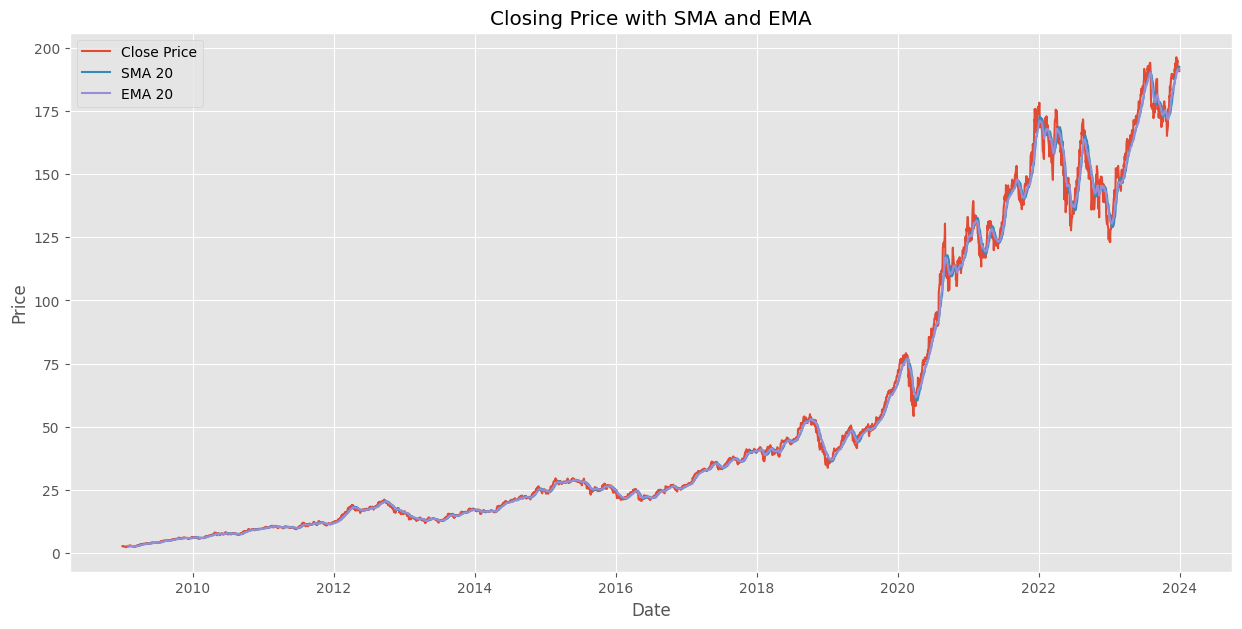

In [21]:
plt.figure(figsize=(15,7))

plt.plot(df1.index, df1['Close'], label='Close Price')
plt.plot(df1.index, df1['SMA_20'], label='SMA 20')
plt.plot(df1.index, df1['EMA_20'], label='EMA 20')

plt.title('Closing Price with SMA and EMA')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

B. RSI Plot

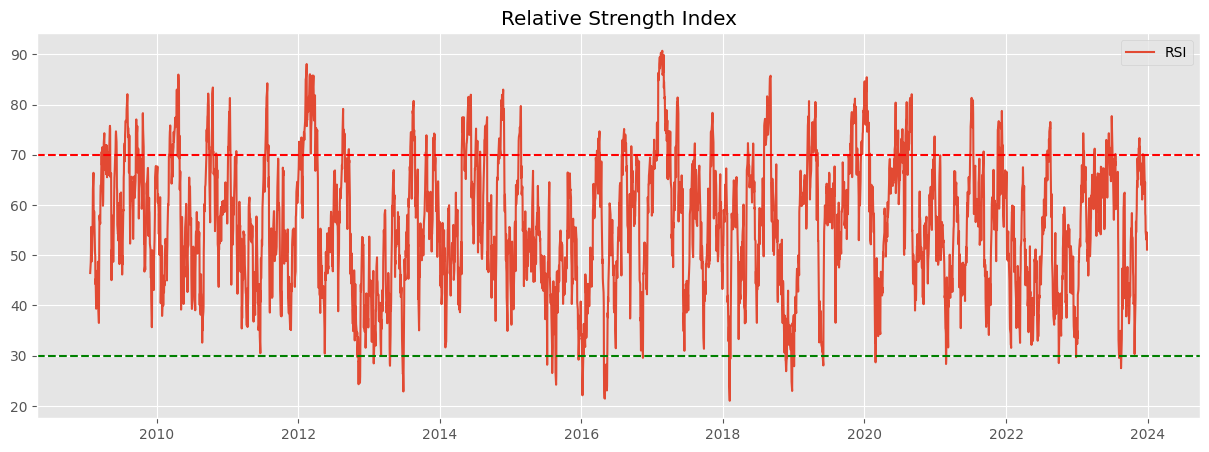

In [22]:
plt.figure(figsize=(15,5))

plt.plot(df1.index, df1['RSI'], label='RSI')

plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title('Relative Strength Index')
plt.legend()
plt.show()

C. MACD Plot

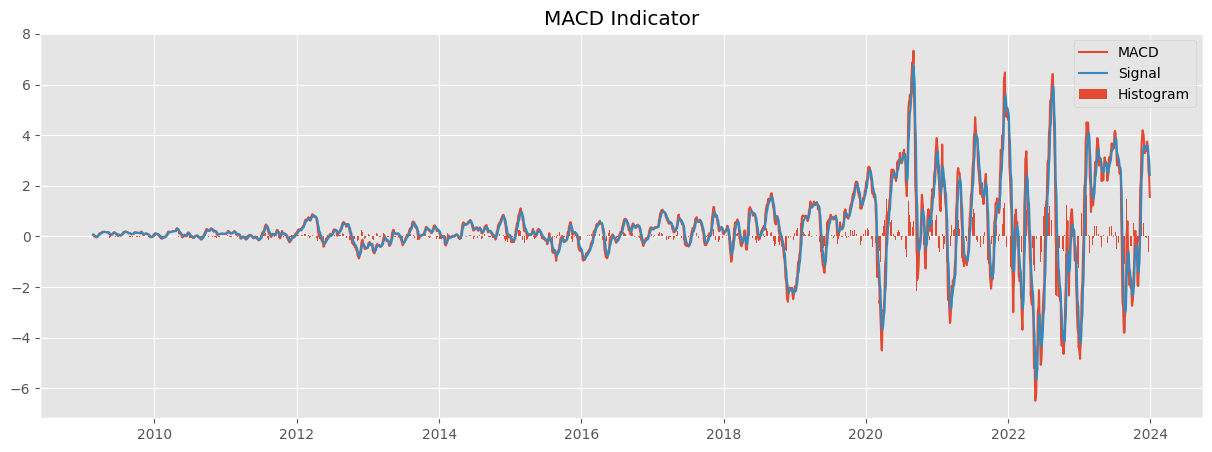

In [23]:
plt.figure(figsize=(15,5))

plt.plot(df1.index, df1['MACD'], label='MACD')
plt.plot(df1.index, df1['MACD_Signal'], label='Signal')

plt.bar(df1.index, df1['MACD_Hist'], label='Histogram')

plt.title('MACD Indicator')
plt.legend()
plt.show()

Analyze All 5 Datasets Using a Function
First: Create a Function

Analyze All 5 Datasets Using a Function
First: Create a Function

In [24]:
def analyze_stock(df, stock_name):

    # -----------------------------
    # Data Cleaning
    # -----------------------------
    
    df['Date'] = pd.to_datetime(df['Date'])
    
    df.set_index('Date', inplace=True)

    cols = ['Open', 'High', 'Low', 'Close', 'Volume']

    df[cols] = df[cols].astype(float)

    df.fillna(method='ffill', inplace=True)

    
    # -----------------------------
    # Technical Indicators
    # -----------------------------

    # SMA
    df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
    df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

    # EMA
    df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
    df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)

    # RSI
    df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

    # MACD
    macd, macd_signal, macd_hist = talib.MACD(
        df['Close'],
        fastperiod=12,
        slowperiod=26,
        signalperiod=9
    )

    df['MACD'] = macd
    df['MACD_Signal'] = macd_signal
    df['MACD_Hist'] = macd_hist


    # -----------------------------
    # Financial Metrics
    # -----------------------------

    df['Daily_Return'] = df['Close'].pct_change()

    average_return = df['Daily_Return'].mean()

    volatility = df['Daily_Return'].std()

    sharpe_ratio = (average_return / volatility) * np.sqrt(252)

    print(f"\n===== {stock_name} =====")
    print(f"Average Daily Return: {average_return:.5f}")
    print(f"Volatility: {volatility:.5f}")
    print(f"Sharpe Ratio: {sharpe_ratio:.5f}")


    # -----------------------------
    # Visualization 1
    # Closing Price + Moving Averages
    # -----------------------------

    plt.figure(figsize=(15,7))

    plt.plot(df.index, df['Close'], label='Close Price')

    plt.plot(df.index, df['SMA_20'], label='SMA 20')

    plt.plot(df.index, df['EMA_20'], label='EMA 20')

    plt.title(f'{stock_name} Closing Price with SMA and EMA')

    plt.xlabel('Date')

    plt.ylabel('Price')

    plt.legend()

    plt.show()


    # -----------------------------
    # Visualization 2
    # RSI
    # -----------------------------

    plt.figure(figsize=(15,5))

    plt.plot(df.index, df['RSI'], label='RSI')

    plt.axhline(70, color='red', linestyle='--')

    plt.axhline(30, color='green', linestyle='--')

    plt.title(f'{stock_name} RSI')

    plt.legend()

    plt.show()


    # -----------------------------
    # Visualization 3
    # MACD
    # -----------------------------

    plt.figure(figsize=(15,5))

    plt.plot(df.index, df['MACD'], label='MACD')

    plt.plot(df.index, df['MACD_Signal'], label='Signal')

    plt.bar(df.index, df['MACD_Hist'], label='Histogram')

    plt.title(f'{stock_name} MACD')

    plt.legend()

    plt.show()


    # -----------------------------
    # Correlation Heatmap
    # -----------------------------

    plt.figure(figsize=(10,8))

    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

    plt.title(f'{stock_name} Correlation Matrix')

    plt.show()


    return df

In [25]:
df1 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\AAPL.csv")
df2 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\AMZN.csv")
df3 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\GOOG.csv")
df4 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\META.csv")
df5 = pd.read_csv(r"C:\\Users\\yordi\\OneDrive\\Desktop\\10 Acadamy\\Week1\\yfinance_data\\Data\\NVDA.csv")


===== Stock 1 =====
Average Daily Return: 0.00129
Volatility: 0.01801
Sharpe Ratio: 1.13625


C:\Users\yordi\AppData\Local\Temp\ipykernel_47084\1786636233.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


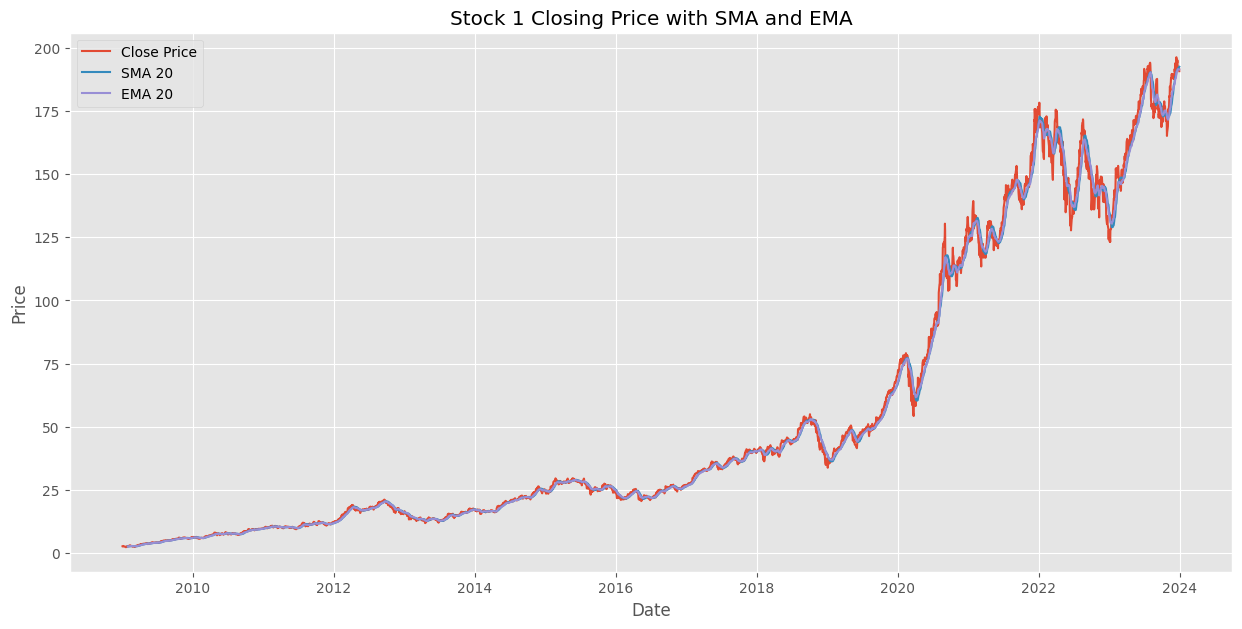

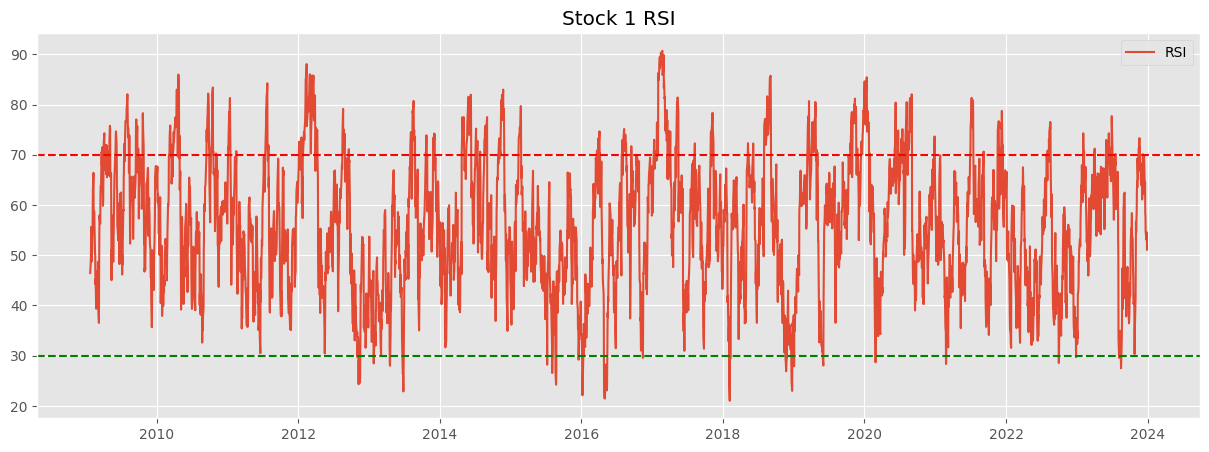

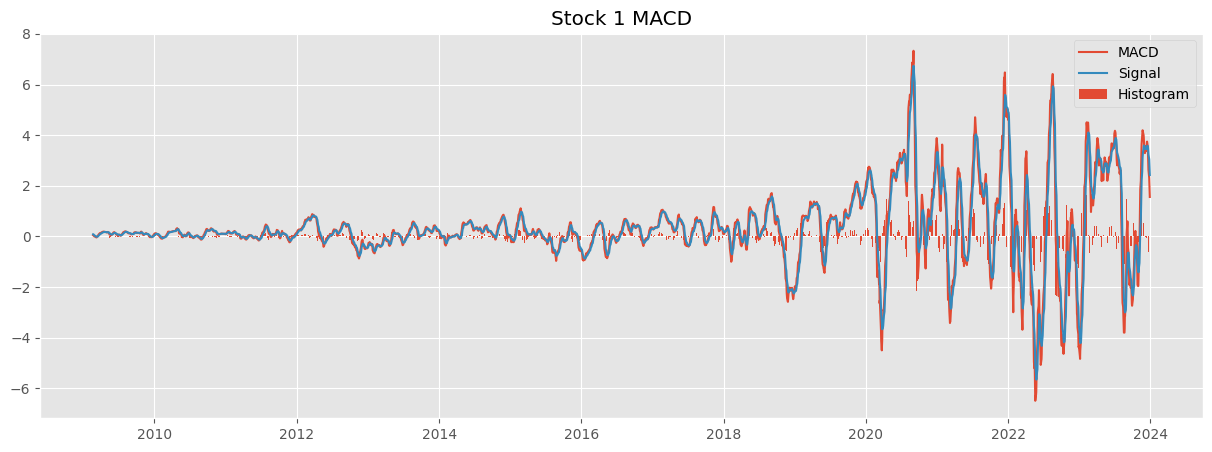

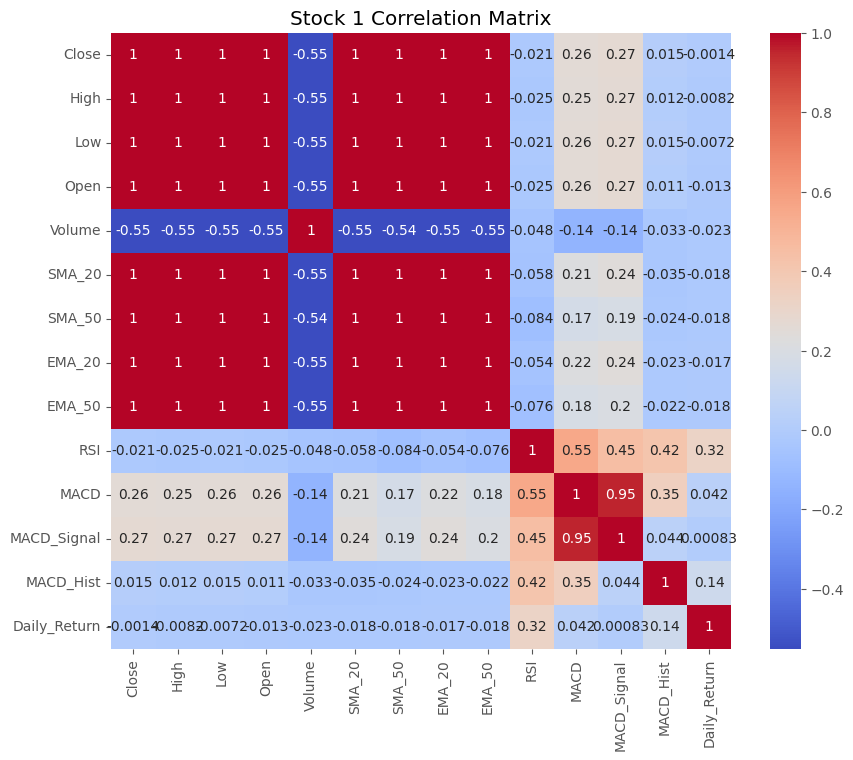


===== Stock 2 =====
Average Daily Return: 0.00130
Volatility: 0.02183
Sharpe Ratio: 0.94725


C:\Users\yordi\AppData\Local\Temp\ipykernel_47084\1786636233.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


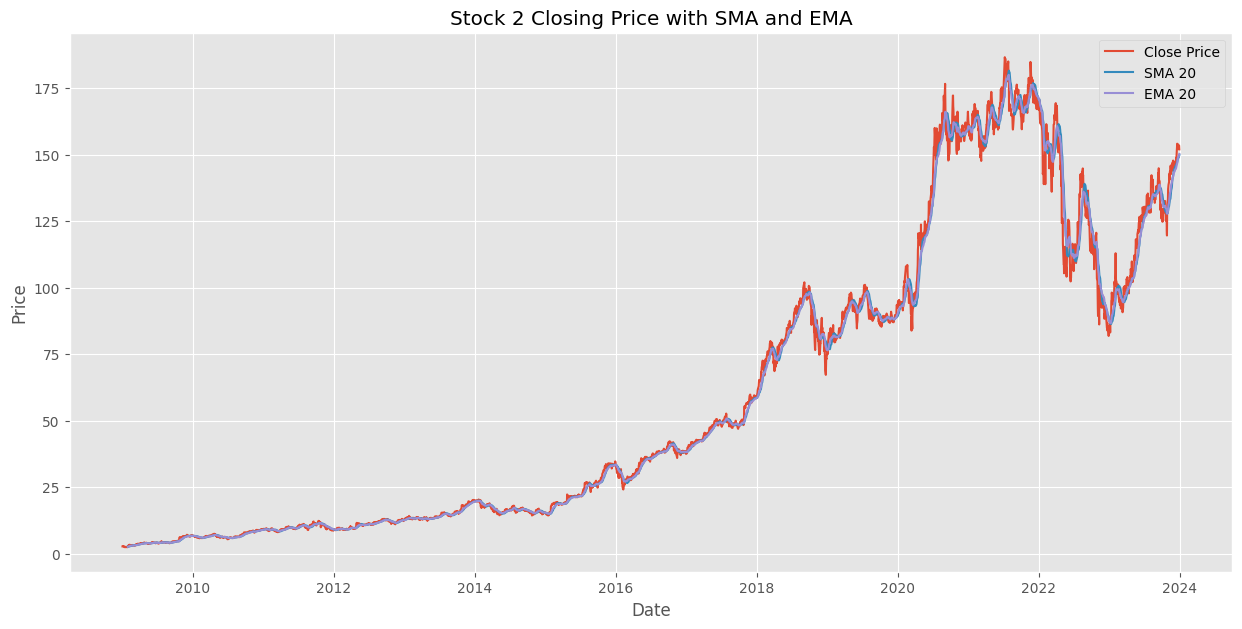

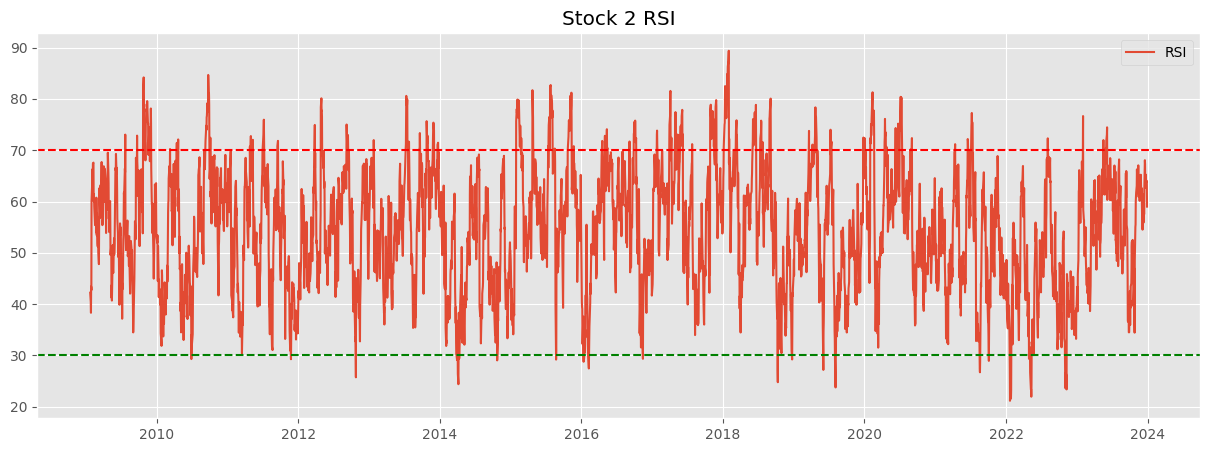

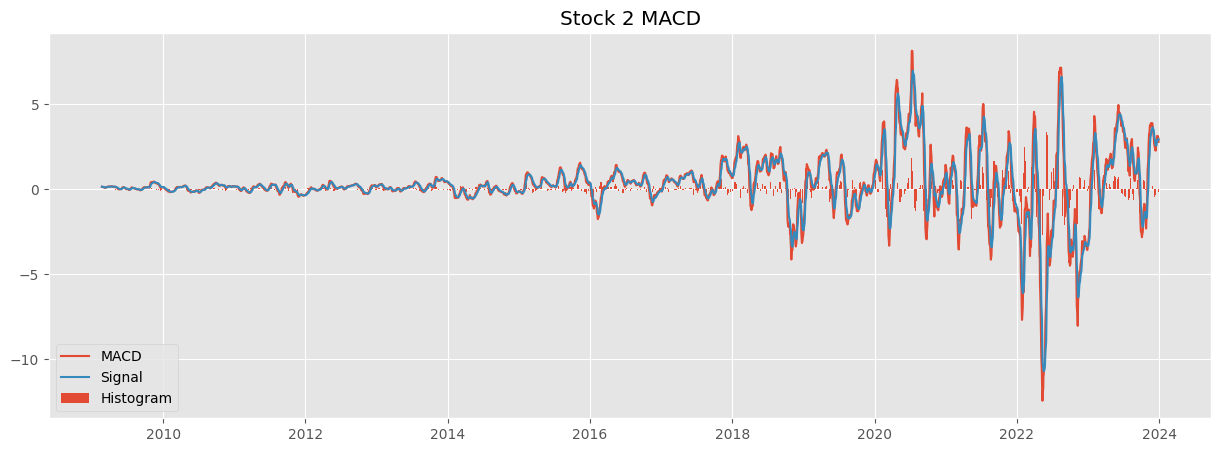

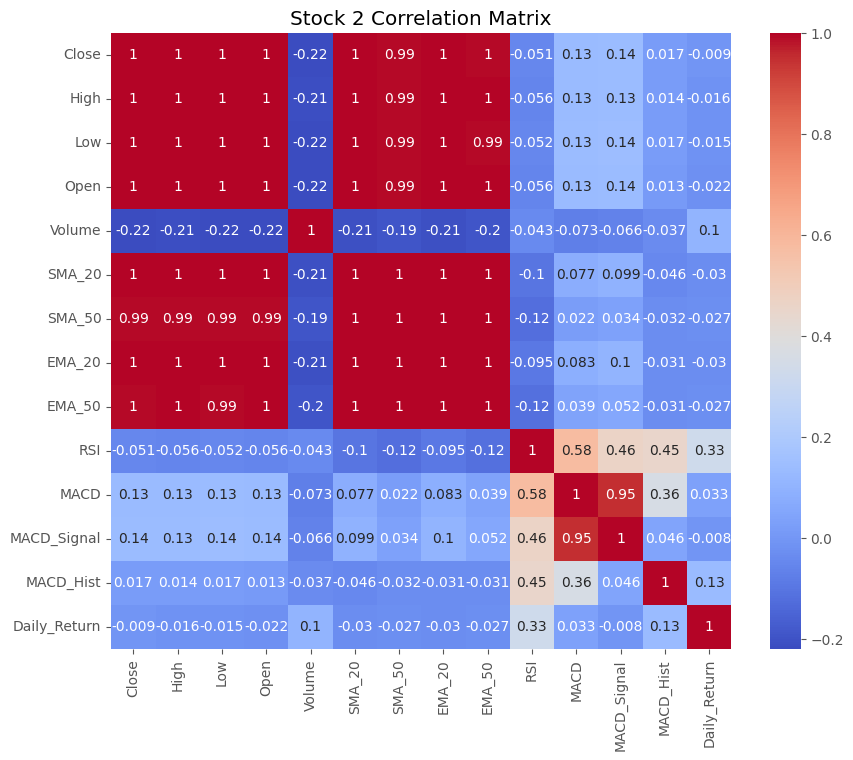


===== Stock 3 =====
Average Daily Return: 0.00091
Volatility: 0.01733
Sharpe Ratio: 0.83356


C:\Users\yordi\AppData\Local\Temp\ipykernel_47084\1786636233.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


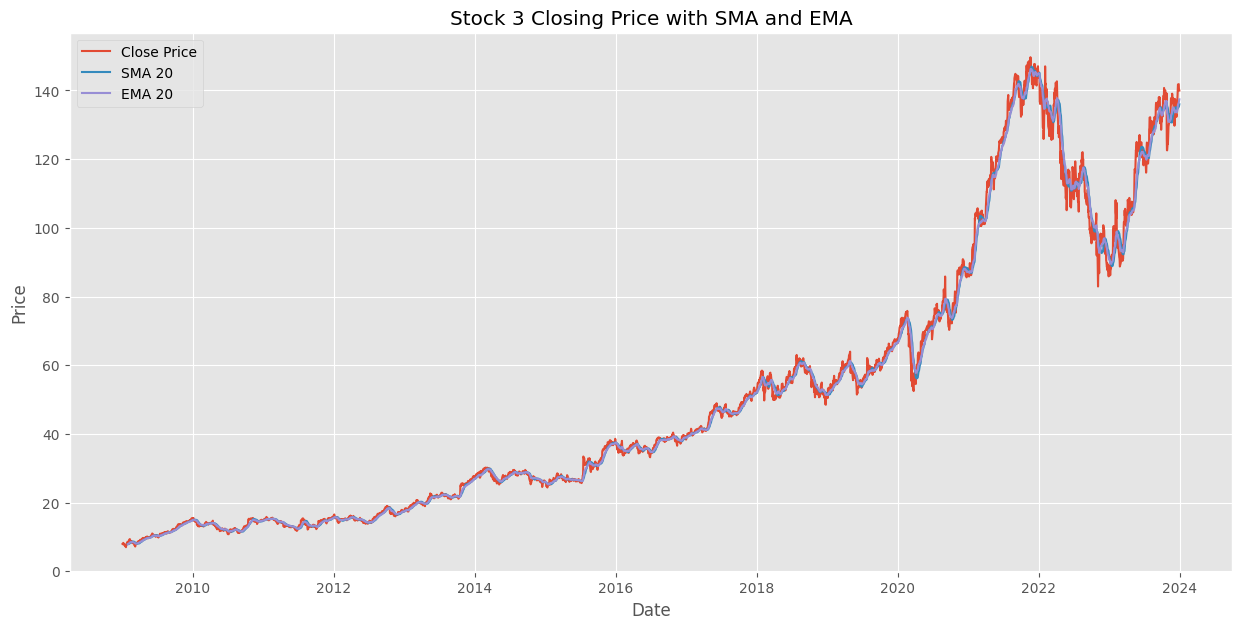

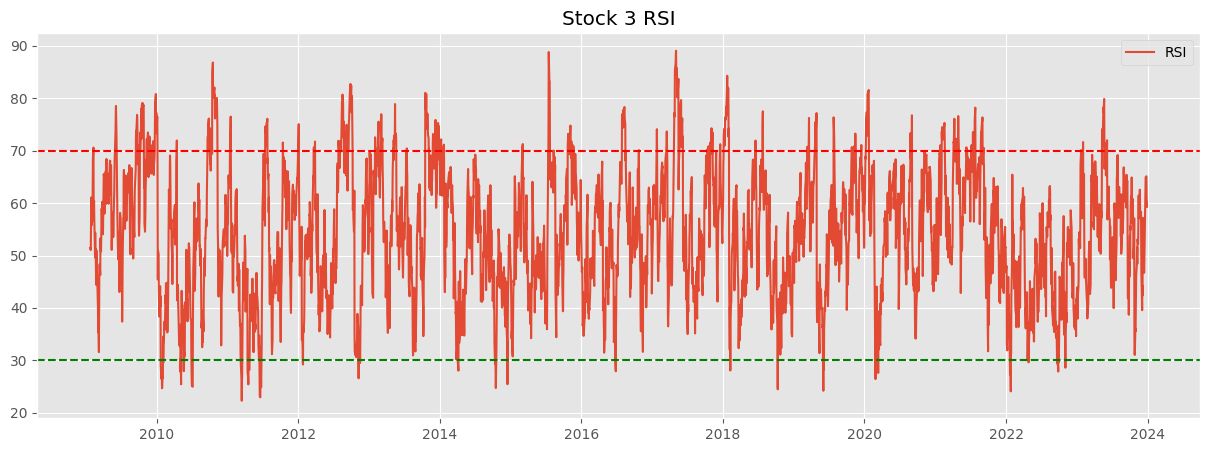

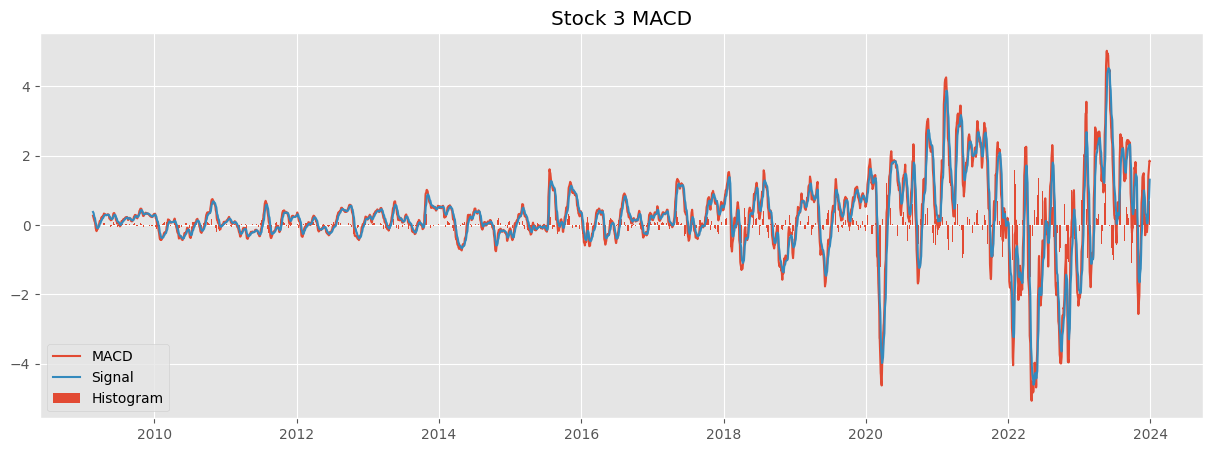

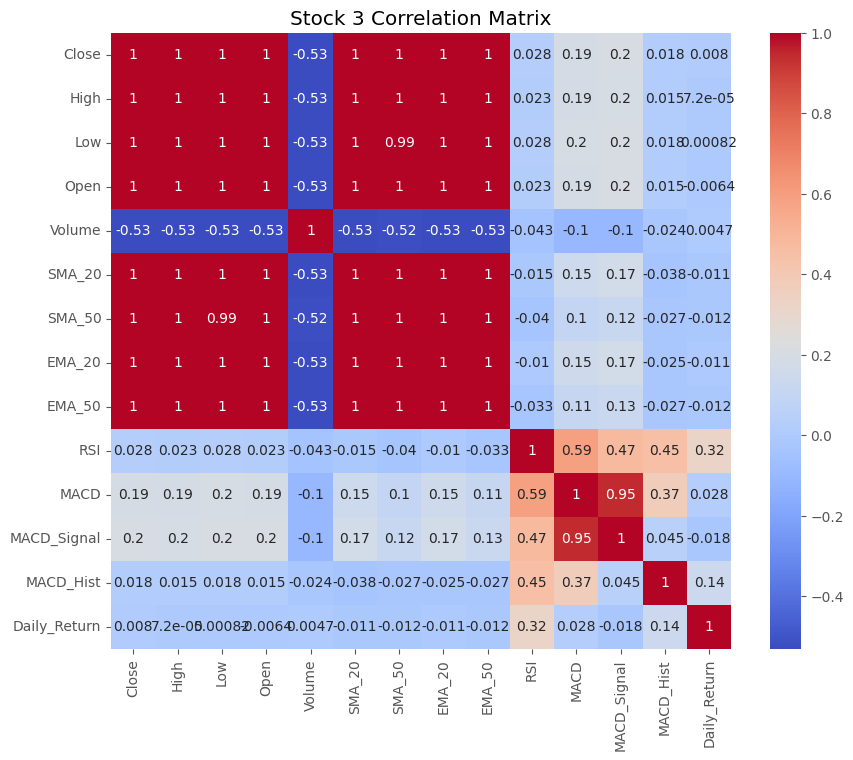


===== Stock 4 =====
Average Daily Return: 0.00108
Volatility: 0.02528
Sharpe Ratio: 0.67936


C:\Users\yordi\AppData\Local\Temp\ipykernel_47084\1786636233.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


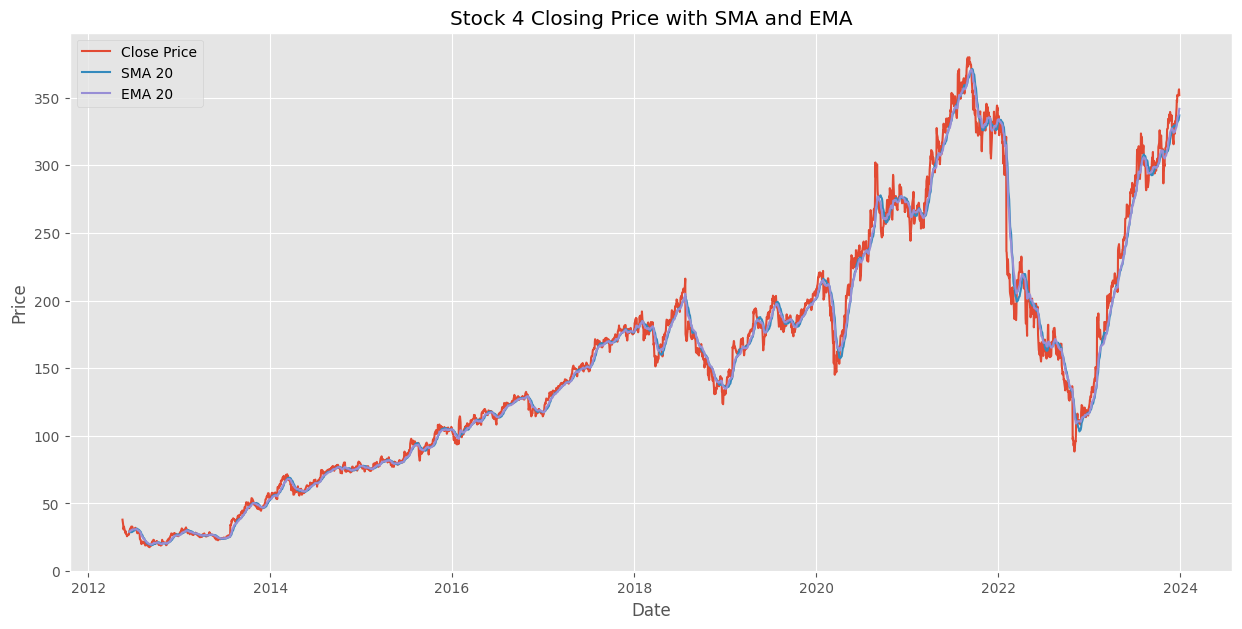

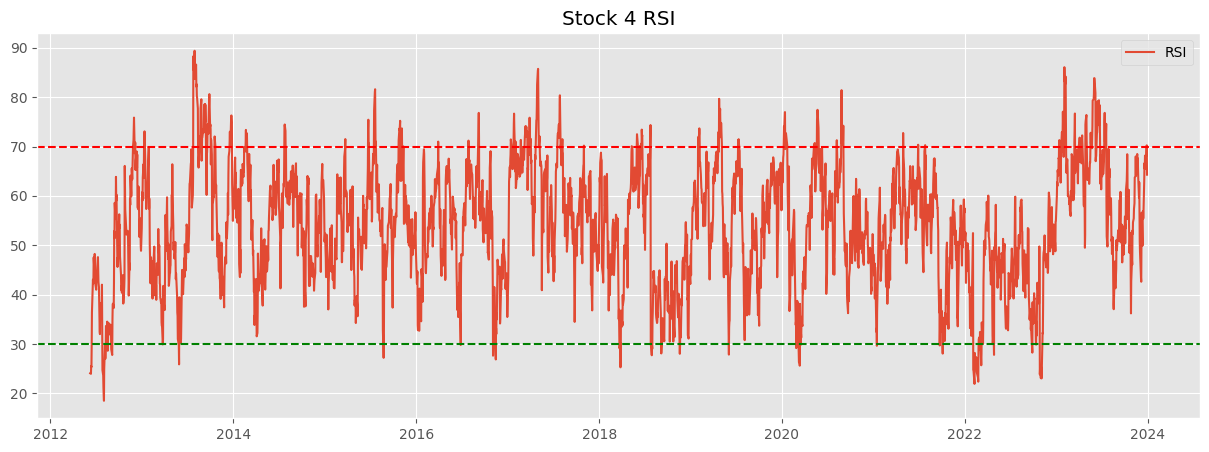

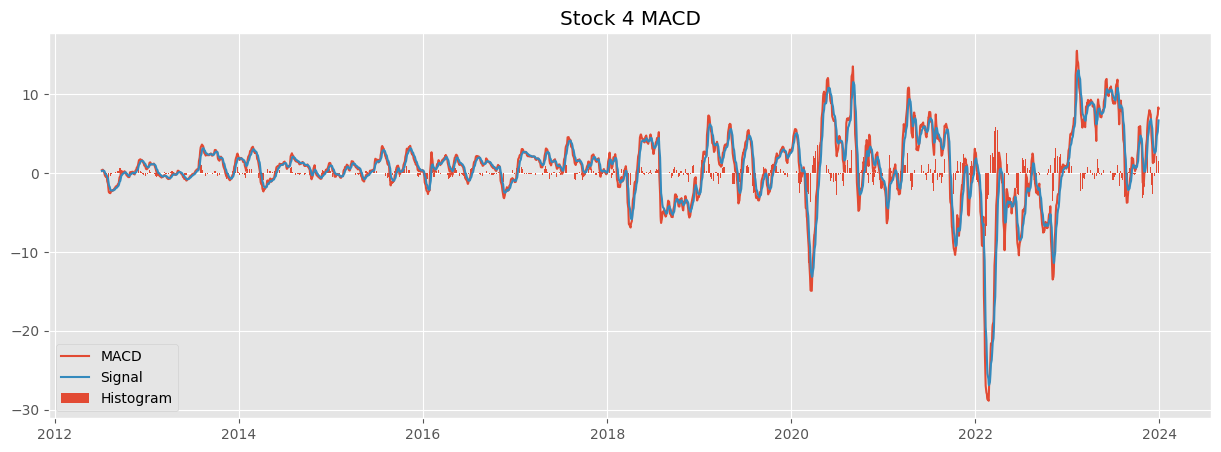

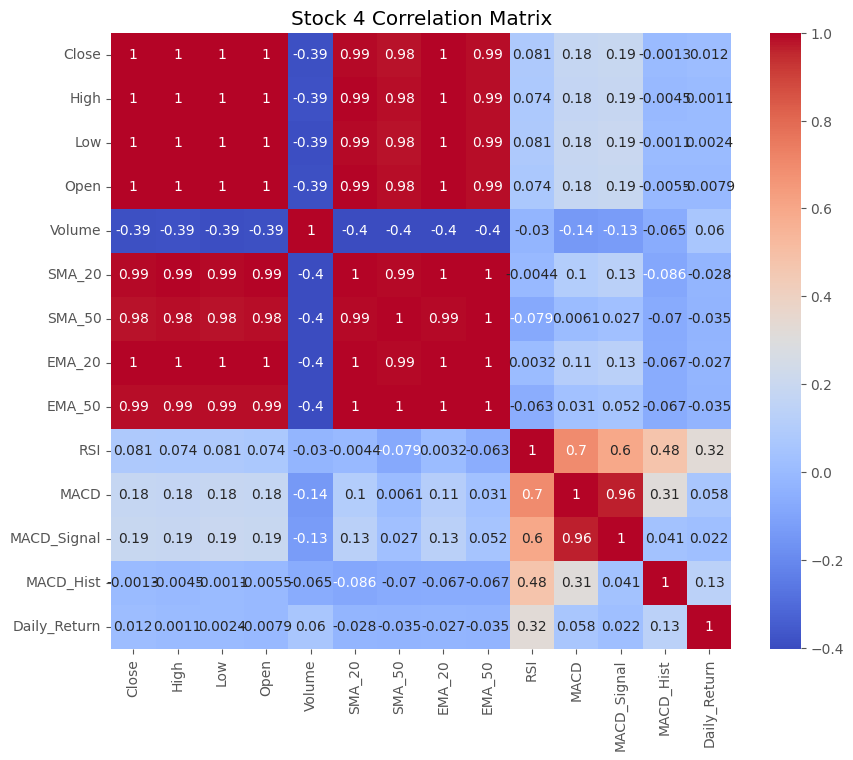


===== Stock 5 =====
Average Daily Return: 0.00188
Volatility: 0.02892
Sharpe Ratio: 1.03037


C:\Users\yordi\AppData\Local\Temp\ipykernel_47084\1786636233.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


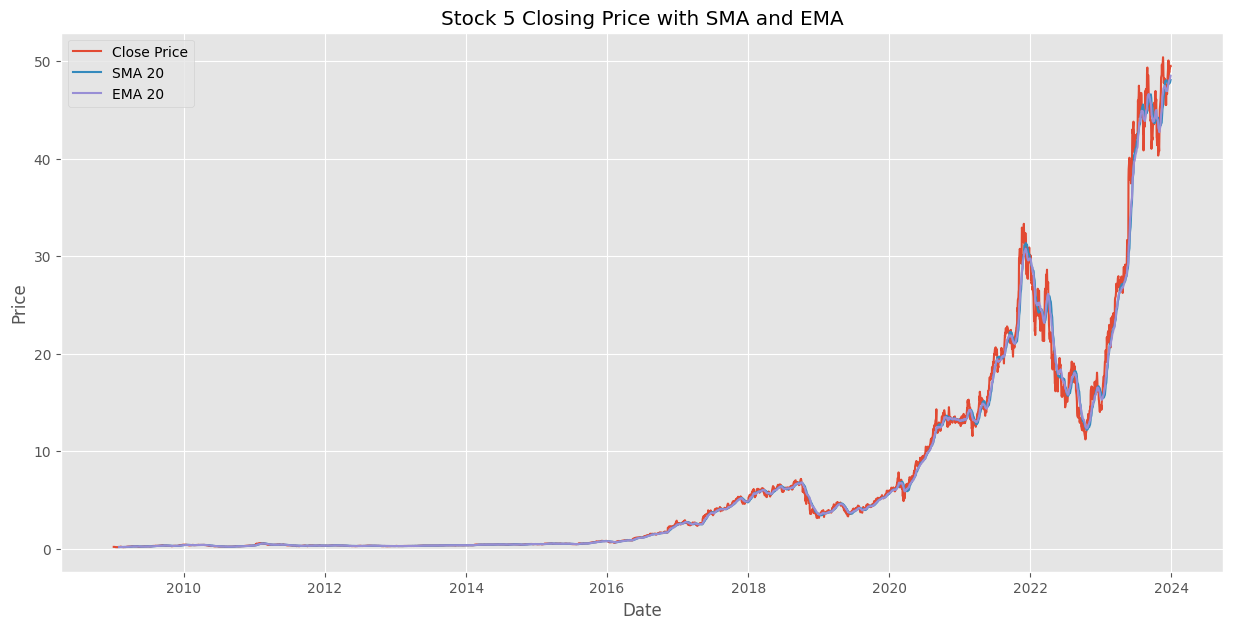

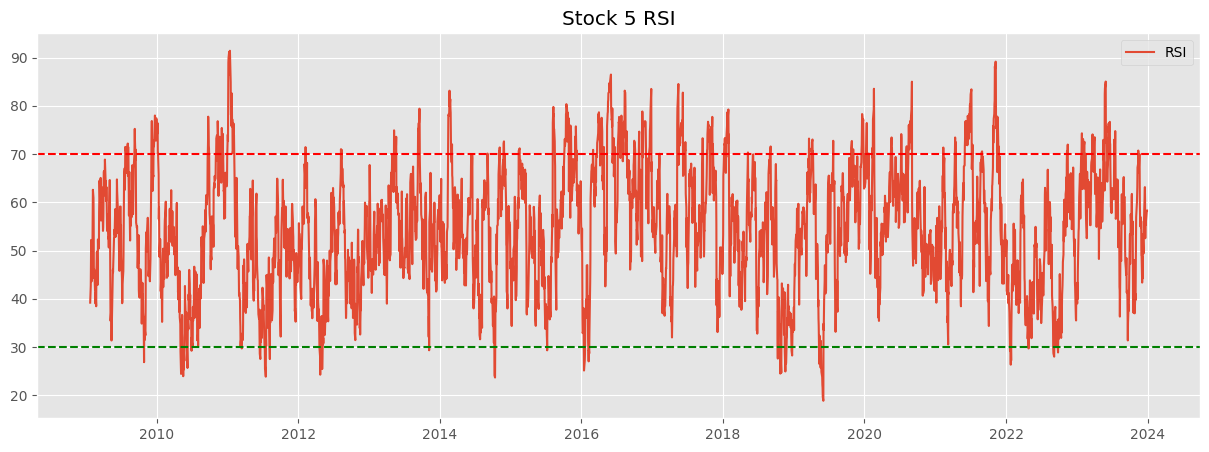

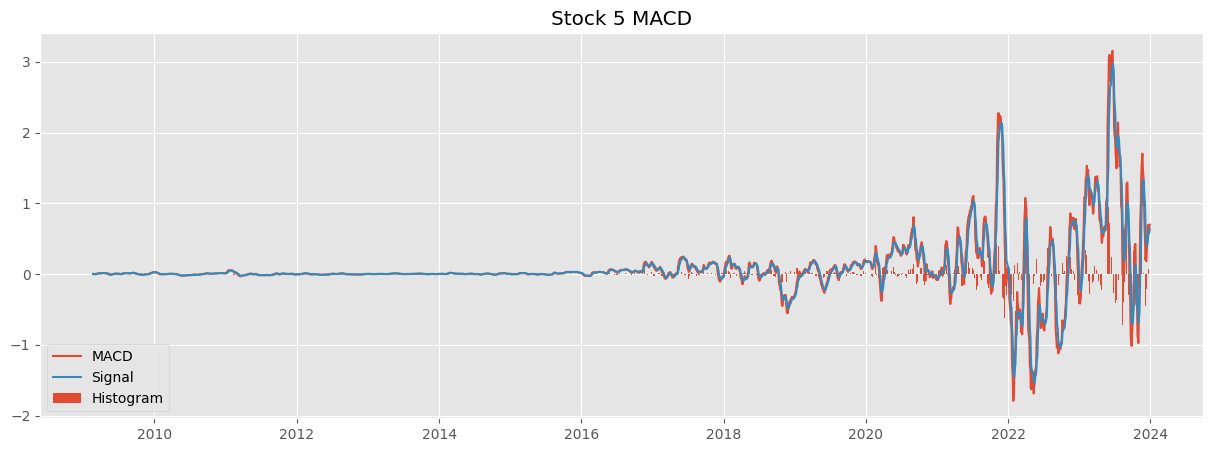

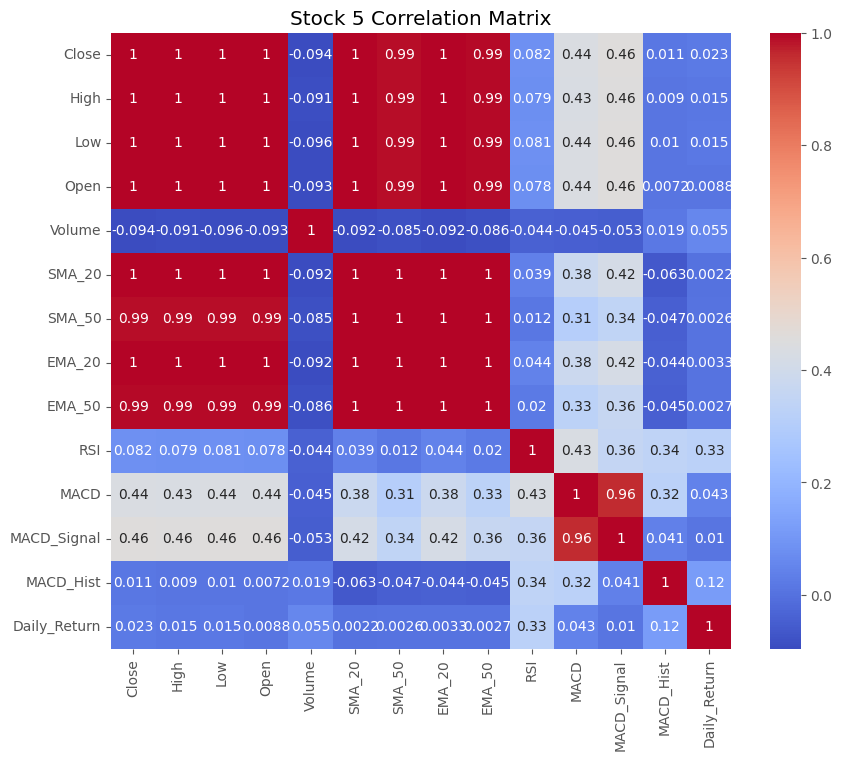

In [26]:
stock1 = analyze_stock(df1, "Stock 1")

stock2 = analyze_stock(df2, "Stock 2")

stock3 = analyze_stock(df3, "Stock 3")

stock4 = analyze_stock(df4, "Stock 4")

stock5 = analyze_stock(df5, "Stock 5")